--- Memuat Dataset ---
Dataset berhasil dimuat.

--- Informasi Dasar Train Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   school_name              712 non-null    object 
 1   state                    722 non-null    object 
 2   school_type              700 non-null    object 
 3   grade_level              723 non-null    object 
 4   funding_per_student_usd  713 non-null    float64
 5   avg_test_score_percent   729 non-null    float64
 6   student_teacher_ratio    725 non-null    float64
 7   percent_low_income       702 non-null    float64
 8   percent_minority         727 non-null    float64
 9   internet_access_percent  709 non-null    float64
 10  dropout_rate_percent     800 non-null    float64
dtypes: float64(7), object(4)
memory usage: 68.9+ KB

--- Statistik Deskriptif Train Dataset ---
       fu

C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_39388\1576312416.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis')


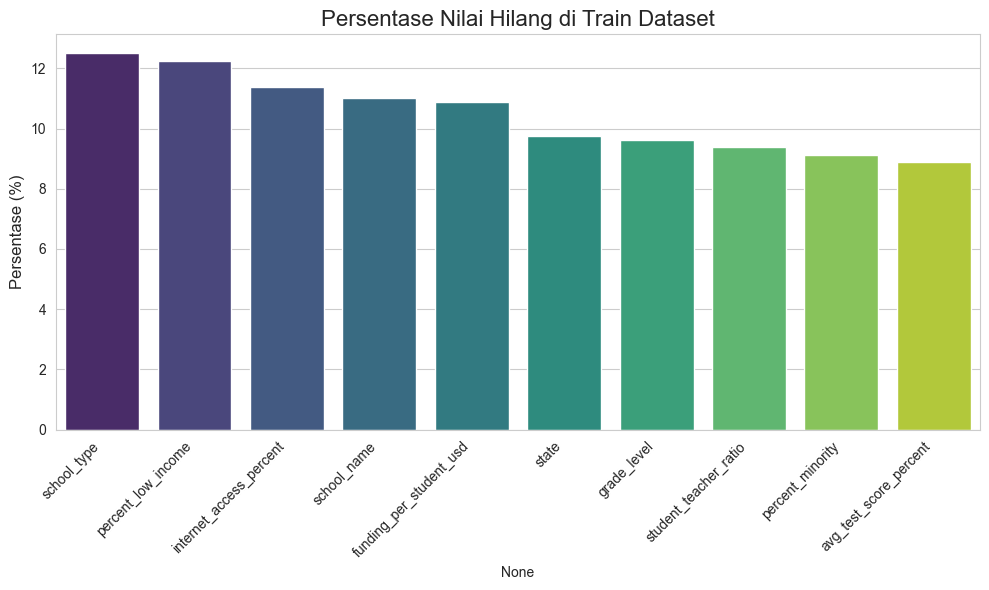


--- Menganalisis Variabel Target ---


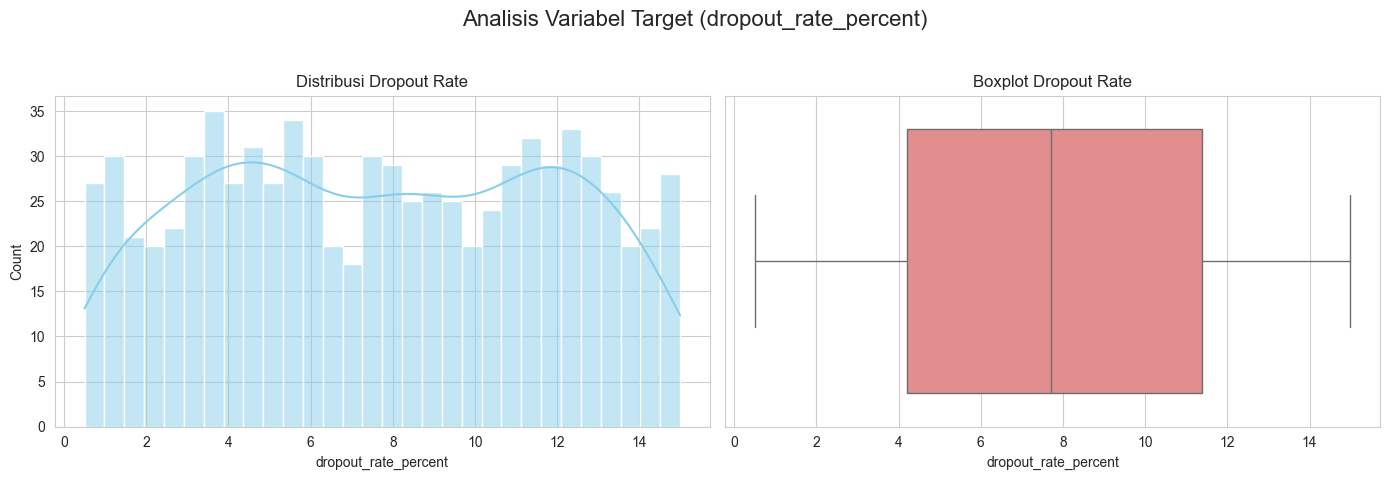


--- Menganalisis Korelasi Variabel Numerik ---


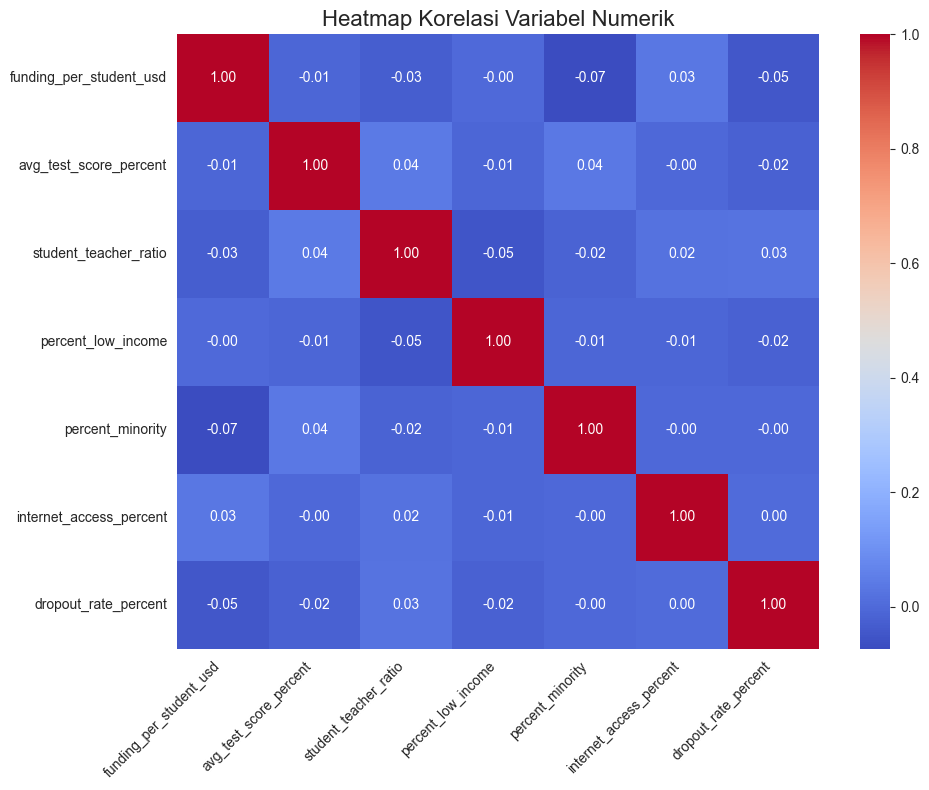


--- Menganalisis Variabel Kategorikal ---


C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_39388\1576312416.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=feature, y='dropout_rate_percent', data=train_df, order=order, palette='crest')


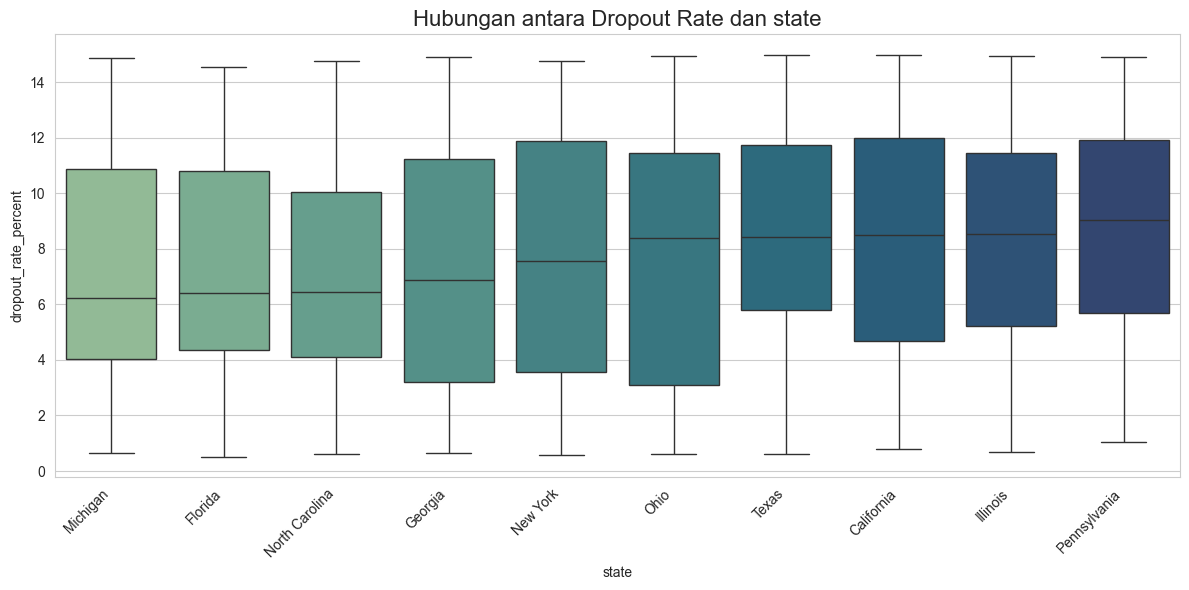

C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_39388\1576312416.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=feature, y='dropout_rate_percent', data=train_df, order=order, palette='crest')


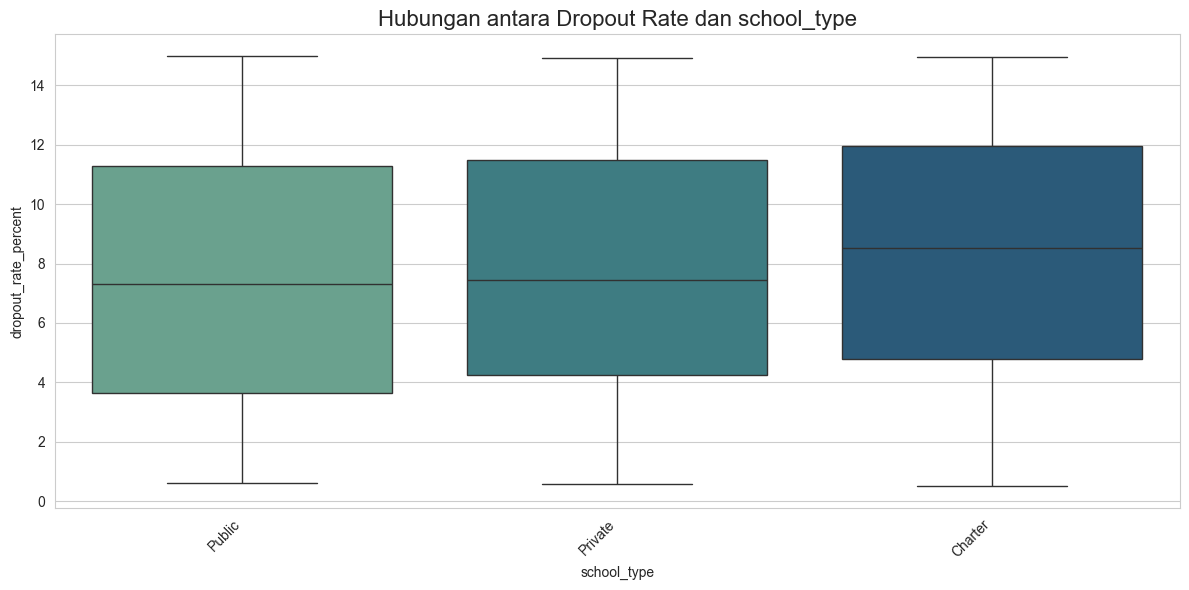

C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_39388\1576312416.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=feature, y='dropout_rate_percent', data=train_df, order=order, palette='crest')


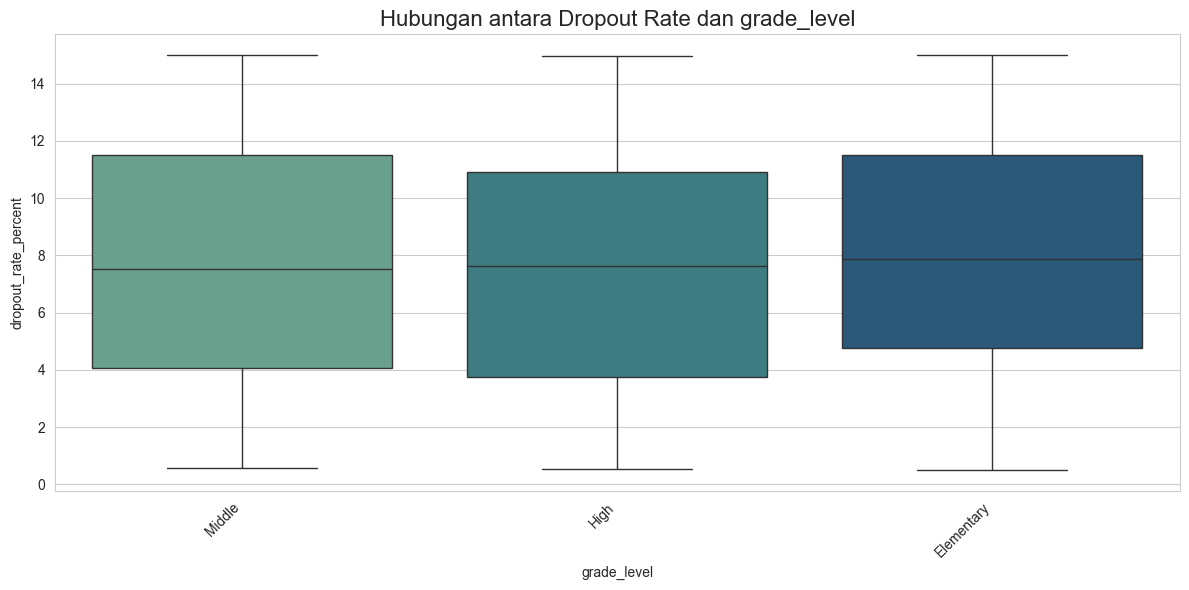

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Atur style untuk visualisasi
sns.set_style("whitegrid")

# --- MEMUAT DATASET ---
print("--- Memuat Dataset ---")
try:
    train_df = pd.read_csv("C:/Uner/Lomba/Shine/rumpun-penalaran-2025-data-science-competition/train_dataset.csv")
    test_df = pd.read_csv("C:/Uner/Lomba/Shine/rumpun-penalaran-2025-data-science-competition/test_dataset.csv")
    print("Dataset berhasil dimuat.\n")
except FileNotFoundError:
    print("Error: Pastikan file 'train_dataset.csv' dan 'test_dataset.csv' berada di direktori yang sama.")
    # Hentikan eksekusi jika file tidak ditemukan
    exit()

# --- INFORMASI DASAR DATASET ---
print("--- Informasi Dasar Train Dataset ---")
train_df.info()

print("\n--- Statistik Deskriptif Train Dataset ---")
print(train_df.describe())

print("\n--- 5 Baris Pertama Train Dataset ---")
print(train_df.head())

# --- ANALISIS NILAI HILANG (MISSING VALUES) ---
print("\n--- Menganalisis Nilai Hilang ---")
plt.figure(figsize=(10, 6))
missing_values = train_df.isnull().sum() / len(train_df) * 100
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
if not missing_values.empty:
    sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis')
    plt.title('Persentase Nilai Hilang di Train Dataset', fontsize=16)
    plt.ylabel('Persentase (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada nilai hilang di train dataset.")

# --- ANALISIS VARIABEL TARGET (DROPOUT_RATE_PERCENT) ---
print("\n--- Menganalisis Variabel Target ---")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train_df['dropout_rate_percent'], kde=True, bins=30, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Dropout Rate')
sns.boxplot(x=train_df['dropout_rate_percent'], ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot Dropout Rate')
plt.suptitle('Analisis Variabel Target (dropout_rate_percent)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- ANALISIS KORELASI VARIABEL NUMERIK ---
print("\n--- Menganalisis Korelasi Variabel Numerik ---")
plt.figure(figsize=(10, 8))
numerical_cols = train_df.select_dtypes(include=np.number).columns.tolist()
correlation_matrix = train_df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Heatmap Korelasi Variabel Numerik', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- ANALISIS VARIABEL KATEGORIKAL ---
print("\n--- Menganalisis Variabel Kategorikal ---")
categorical_features = ['state', 'school_type', 'grade_level']
for feature in categorical_features:
    plt.figure(figsize=(12, 6))
    order = train_df.groupby(feature)['dropout_rate_percent'].median().sort_values().index
    sns.boxplot(x=feature, y='dropout_rate_percent', data=train_df, order=order, palette='crest')
    plt.title(f'Hubungan antara Dropout Rate dan {feature}', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Pre-Processing

In [52]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from xgboost import XGBRegressor  # Import XGBoost Regressor
from sklearn.preprocessing import StandardScaler

# --- MEMUAT DATASET ---
print("--- Memuat Dataset ---")
try:
    train_df = pd.read_csv("C:/Uner/Lomba/Shine/rumpun-penalaran-2025-data-science-competition/train_dataset.csv")
    test_df = pd.read_csv("C:/Uner/Lomba/Shine/rumpun-penalaran-2025-data-science-competition/test_dataset.csv")
    print("Dataset berhasil dimuat.\n")
except FileNotFoundError:
    print("Error: Pastikan file 'train_dataset.csv' dan 'test_dataset.csv' berada di direktori yang sama.")
    exit()

# --- PRA-PEMROSESAN DATA (VERSI DITINGKATKAN) ---

# 1. Gabungkan data train dan test
y_target = train_df['dropout_rate_percent']
test_ids = test_df['id']
train_df.drop('dropout_rate_percent', axis=1, inplace=True)
combined_df = pd.concat([train_df, test_df], ignore_index=True)
combined_df.drop(['school_name', 'id'], axis=1, inplace=True, errors='ignore')
print("Data train dan test digabungkan untuk pra-pemrosesan.")

# 2. Pisahkan kolom numerik dan kategorikal
numeric_cols = combined_df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = combined_df.select_dtypes(include=['object']).columns.tolist()

# 3. Penanganan Nilai Hilang (Missing Value Imputation)
print("\n--- Menangani Nilai Hilang ---")
# Untuk kolom KATEGORIKAL, kita tetap gunakan modus
for col in categorical_cols:
    mode_val = combined_df[col].mode()[0]
    combined_df[col].fillna(mode_val, inplace=True)
    print(f"Nilai hilang di kolom kategorikal '{col}' diisi dengan modus ('{mode_val}').")

# Untuk kolom NUMERIK, gunakan IterativeImputer dengan XGBoost
print("\nMenggunakan IterativeImputer untuk kolom numerik...")
imputer = IterativeImputer(estimator=XGBRegressor(n_estimators=100, random_state=42), max_iter=10, random_state=42)
combined_df[numeric_cols] = imputer.fit_transform(combined_df[numeric_cols])
print("Imputasi nilai hilang pada kolom numerik selesai.")

# 4. Rekayasa Fitur (Feature Engineering)
print("\n--- Membuat Fitur Baru (Rekayasa Fitur) ---")
epsilon = 1e-6 
combined_df['funding_teacher_ratio'] = combined_df['funding_per_student_usd'] / (combined_df['student_teacher_ratio'] + epsilon)
print("Fitur baru 'funding_teacher_ratio' dibuat.")
combined_df['low_income_minority_interaction'] = combined_df['percent_low_income'] * combined_df['percent_minority']
print("Fitur baru 'low_income_minority_interaction' dibuat.")
combined_df['at_risk_student_percent'] = combined_df['percent_low_income'] + combined_df['percent_minority']
print("Fitur baru 'at_risk_student_percent' dibuat.")

# Tambahkan fitur baru ke daftar kolom numerik untuk scaling
numeric_cols.extend(['funding_teacher_ratio', 'low_income_minority_interaction', 'at_risk_student_percent'])

# 5. Encoding Fitur Kategorikal
print("\n--- Melakukan Encoding pada Fitur Kategorikal ---")
combined_df = pd.get_dummies(combined_df, columns=categorical_cols, drop_first=True, dtype=float)
print("Fitur kategorikal telah di-encode.")

# 6. Scaling Fitur Numerik
print("\n--- Melakukan Scaling pada Fitur Numerik ---")
# Gunakan StandardScaler untuk menormalkan distribusi fitur numerik
scaler = StandardScaler()
# Pastikan hanya kolom numerik yang ada di DataFrame yang di-scale
cols_to_scale = [col for col in numeric_cols if col in combined_df.columns]
combined_df[cols_to_scale] = scaler.fit_transform(combined_df[cols_to_scale])
print("Fitur numerik telah di-scale menggunakan StandardScaler.")

# 7. Pisahkan kembali menjadi data train dan test
print("\n--- Memisahkan Kembali Data ---")
X = combined_df.iloc[:len(train_df)]
X_test = combined_df.iloc[len(train_df):]

print(f"Data training (X) kini memiliki {X.shape[0]} baris dan {X.shape[1]} kolom.")
print(f"Data testing (X_test) kini memiliki {X_test.shape[0]} baris dan {X_test.shape[1]} kolom.")

# --- TAMPILKAN HASIL AKHIR ---
print("\n--- Pra-pemrosesan Selesai ---")
print("Data kini bersih, sepenuhnya numerik, dan siap untuk tahap pemodelan.")
print("\n5 baris pertama dari data training yang telah diproses (X):")
print(X.head())


--- Memuat Dataset ---
Dataset berhasil dimuat.

Data train dan test digabungkan untuk pra-pemrosesan.

--- Menangani Nilai Hilang ---
Nilai hilang di kolom kategorikal 'state' diisi dengan modus ('Texas').
Nilai hilang di kolom kategorikal 'school_type' diisi dengan modus ('Private').
Nilai hilang di kolom kategorikal 'grade_level' diisi dengan modus ('Elementary').

Menggunakan IterativeImputer untuk kolom numerik...


C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_39388\2390536092.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df[col].fillna(mode_val, inplace=True)


Imputasi nilai hilang pada kolom numerik selesai.

--- Membuat Fitur Baru (Rekayasa Fitur) ---
Fitur baru 'funding_teacher_ratio' dibuat.
Fitur baru 'low_income_minority_interaction' dibuat.
Fitur baru 'at_risk_student_percent' dibuat.

--- Melakukan Encoding pada Fitur Kategorikal ---
Fitur kategorikal telah di-encode.

--- Melakukan Scaling pada Fitur Numerik ---
Fitur numerik telah di-scale menggunakan StandardScaler.

--- Memisahkan Kembali Data ---
Data training (X) kini memiliki 800 baris dan 22 kolom.
Data testing (X_test) kini memiliki 200 baris dan 22 kolom.

--- Pra-pemrosesan Selesai ---
Data kini bersih, sepenuhnya numerik, dan siap untuk tahap pemodelan.

5 baris pertama dari data training yang telah diproses (X):
   funding_per_student_usd  avg_test_score_percent  student_teacher_ratio  \
0                 1.487195                1.372588              -0.399907   
1                 1.040263                0.801784               0.185134   
2                -1.416198      

c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


## Modeling

In [53]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
import optuna

# --- MEMUAT DATASET ---
print("--- Memuat Dataset ---")
try:
    train_df = pd.read_csv("C:/Uner/Lomba/Shine/rumpun-penalaran-2025-data-science-competition/train_dataset.csv")
    test_df = pd.read_csv("C:/Uner/Lomba/Shine/rumpun-penalaran-2025-data-science-competition/test_dataset.csv")
    print("Dataset berhasil dimuat.\n")
except FileNotFoundError:
    print("Error: Pastikan file 'train_dataset.csv' dan 'test_dataset.csv' berada di direktori yang sama.")
    exit()

# --- PRA-PEMROSESAN DATA (VERSI DITINGKATKAN) ---

# 1. Gabungkan data train dan test
y_target = train_df['dropout_rate_percent']
test_ids = test_df['id']
train_df.drop('dropout_rate_percent', axis=1, inplace=True)
combined_df = pd.concat([train_df, test_df], ignore_index=True)
combined_df.drop(['school_name', 'id'], axis=1, inplace=True, errors='ignore')
print("Data train dan test digabungkan untuk pra-pemrosesan.")

# 2. Pisahkan kolom numerik dan kategorikal
numeric_cols = combined_df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = combined_df.select_dtypes(include=['object']).columns.tolist()

# 3. Penanganan Nilai Hilang (Missing Value Imputation)
print("\n--- Menangani Nilai Hilang ---")
# Untuk kolom KATEGORIKAL, kita tetap gunakan modus
for col in categorical_cols:
    mode_val = combined_df[col].mode()[0]
    combined_df[col].fillna(mode_val, inplace=True)
    print(f"Nilai hilang di kolom kategorikal '{col}' diisi dengan modus ('{mode_val}').")

# Untuk kolom NUMERIK, gunakan IterativeImputer dengan XGBoost, CatBoost, atau LightGBM
print("\nMenggunakan IterativeImputer untuk kolom numerik...")

# Pilih model XGBoost, CatBoost, atau LightGBM
model = XGBRegressor(n_estimators=100, random_state=42)  # Anda bisa memilih XGB, CatBoost, atau LightGBM di sini

# Inisialisasi Iterative Imputer
imputer = IterativeImputer(estimator=model, max_iter=10, random_state=42)
combined_df[numeric_cols] = imputer.fit_transform(combined_df[numeric_cols])
print("Imputasi nilai hilang pada kolom numerik selesai.")

# 4. Rekayasa Fitur (Feature Engineering)
print("\n--- Membuat Fitur Baru (Rekayasa Fitur) ---")
epsilon = 1e-6 
combined_df['funding_teacher_ratio'] = combined_df['funding_per_student_usd'] / (combined_df['student_teacher_ratio'] + epsilon)
print("Fitur baru 'funding_teacher_ratio' dibuat.")
combined_df['low_income_minority_interaction'] = combined_df['percent_low_income'] * combined_df['percent_minority']
print("Fitur baru 'low_income_minority_interaction' dibuat.")
combined_df['at_risk_student_percent'] = combined_df['percent_low_income'] + combined_df['percent_minority']
print("Fitur baru 'at_risk_student_percent' dibuat.")

# Tambahkan fitur baru ke daftar kolom numerik untuk scaling
numeric_cols.extend(['funding_teacher_ratio', 'low_income_minority_interaction', 'at_risk_student_percent'])

# 5. Encoding Fitur Kategorikal
print("\n--- Melakukan Encoding pada Fitur Kategorikal ---")
combined_df = pd.get_dummies(combined_df, columns=categorical_cols, drop_first=True, dtype=float)
print("Fitur kategorikal telah di-encode.")

# 6. Scaling Fitur Numerik
print("\n--- Melakukan Scaling pada Fitur Numerik ---")
# Gunakan StandardScaler untuk menormalkan distribusi fitur numerik
scaler = StandardScaler()
# Pastikan hanya kolom numerik yang ada di DataFrame yang di-scale
cols_to_scale = [col for col in numeric_cols if col in combined_df.columns]
combined_df[cols_to_scale] = scaler.fit_transform(combined_df[cols_to_scale])
print("Fitur numerik telah di-scale menggunakan StandardScaler.")

# 7. Pisahkan kembali menjadi data train dan test
print("\n--- Memisahkan Kembali Data ---")
X = combined_df.iloc[:len(train_df)]
X_test = combined_df.iloc[len(train_df):]

print(f"Data training (X) kini memiliki {X.shape[0]} baris dan {X.shape[1]} kolom.")
print(f"Data testing (X_test) kini memiliki {X_test.shape[0]} baris dan {X_test.shape[1]} kolom.")

# --- TUNING HYPERPARAMETER DENGAN GRIDSEARCHCV ---
print("\n--- Tuning Model dengan GridSearchCV ---")
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, verbose=1, n_jobs=-1)
grid_search.fit(X, y_target)

# Tampilkan hasil terbaik dari GridSearch
print("Best parameters found: ", grid_search.best_params_)

# --- TUNING HYPERPARAMETER DENGAN OPTUNA ---
print("\n--- Tuning Model dengan Optuna ---")
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 200),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'random_state': 42
    }

    model = XGBRegressor(**param)
    model.fit(X, y_target)
    return model.score(X, y_target)

# Use Optuna to optimize the model
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# Print the best parameters
print("Best parameters from Optuna: ", study.best_params)

# --- TAMPILKAN HASIL AKHIR ---
print("\n--- Pra-pemrosesan Selesai ---")
print("Data kini bersih, sepenuhnya numerik, dan siap untuk tahap pemodelan.")
print("\n5 baris pertama dari data training yang telah diproses (X):")
print(X.head())


C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_39388\1119565148.py:41: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df[col].fillna(mode_val, inplace=True)


--- Memuat Dataset ---
Dataset berhasil dimuat.

Data train dan test digabungkan untuk pra-pemrosesan.

--- Menangani Nilai Hilang ---
Nilai hilang di kolom kategorikal 'state' diisi dengan modus ('Texas').
Nilai hilang di kolom kategorikal 'school_type' diisi dengan modus ('Private').
Nilai hilang di kolom kategorikal 'grade_level' diisi dengan modus ('Elementary').

Menggunakan IterativeImputer untuk kolom numerik...


c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Imputasi nilai hilang pada kolom numerik selesai.

--- Membuat Fitur Baru (Rekayasa Fitur) ---
Fitur baru 'funding_teacher_ratio' dibuat.
Fitur baru 'low_income_minority_interaction' dibuat.
Fitur baru 'at_risk_student_percent' dibuat.

--- Melakukan Encoding pada Fitur Kategorikal ---
Fitur kategorikal telah di-encode.

--- Melakukan Scaling pada Fitur Numerik ---
Fitur numerik telah di-scale menggunakan StandardScaler.

--- Memisahkan Kembali Data ---
Data training (X) kini memiliki 800 baris dan 22 kolom.
Data testing (X_test) kini memiliki 200 baris dan 22 kolom.

--- Tuning Model dengan GridSearchCV ---
Fitting 3 folds for each of 18 candidates, totalling 54 fits


[I 2025-10-13 20:09:05,771] A new study created in memory with name: no-name-26a00ceb-60aa-43ec-b03e-2fa3d1de484f
C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_39388\1119565148.py:109: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
[I 2025-10-13 20:09:05,917] Trial 0 finished with value: 0.5800854737190179 and parameters: {'n_estimators': 150, 'learning_rate': 0.03347581587175942, 'max_depth': 5}. Best is trial 0 with value: 0.5800854737190179.


Best parameters found:  {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}

--- Tuning Model dengan Optuna ---


C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_39388\1119565148.py:109: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
[I 2025-10-13 20:09:06,161] Trial 1 finished with value: 0.5548582892024497 and parameters: {'n_estimators': 162, 'learning_rate': 0.013824747320375263, 'max_depth': 7}. Best is trial 0 with value: 0.5800854737190179.
C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_39388\1119565148.py:109: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
[I 2025-10-13 20:09:06,220] Trial 2 finished with value: 0.5545018057762382 an

Best parameters from Optuna:  {'n_estimators': 197, 'learning_rate': 0.18445118014459674, 'max_depth': 7}

--- Pra-pemrosesan Selesai ---
Data kini bersih, sepenuhnya numerik, dan siap untuk tahap pemodelan.

5 baris pertama dari data training yang telah diproses (X):
   funding_per_student_usd  avg_test_score_percent  student_teacher_ratio  \
0                 1.487195                1.372588              -0.399907   
1                 1.040263                0.801784               0.185134   
2                -1.416198                1.145431              -1.587717   
3                 0.244064               -0.735892               1.497043   
4                -1.028958                1.110484              -0.399907   

   percent_low_income  percent_minority  internet_access_percent  \
0           -0.682954         -0.918867                 0.910892   
1           -1.484641          0.790307                -0.043979   
2           -0.002603          0.329361                -1.471156

C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_39388\2203728881.py:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df[col].fillna(mode_val, inplace=True)


--- Memuat Dataset ---
Dataset berhasil dimuat.

Data train dan test digabungkan untuk pra-pemrosesan.

--- Menangani Nilai Hilang ---
Nilai hilang di kolom kategorikal 'state' diisi dengan modus ('Texas').
Nilai hilang di kolom kategorikal 'school_type' diisi dengan modus ('Private').
Nilai hilang di kolom kategorikal 'grade_level' diisi dengan modus ('Elementary').

Menggunakan IterativeImputer untuk kolom numerik...
Learning rate set to 0.262518
0:	learn: 17.5324027	total: 1.48ms	remaining: 146ms
1:	learn: 17.3905403	total: 2.51ms	remaining: 123ms
2:	learn: 17.3324690	total: 3.69ms	remaining: 119ms
3:	learn: 17.1205585	total: 4.93ms	remaining: 118ms
4:	learn: 17.0089596	total: 5.87ms	remaining: 112ms
5:	learn: 16.9471765	total: 6.87ms	remaining: 108ms
6:	learn: 16.8615173	total: 8.24ms	remaining: 110ms
7:	learn: 16.7693951	total: 9.19ms	remaining: 106ms
8:	learn: 16.6957961	total: 10.1ms	remaining: 102ms
9:	learn: 16.6216527	total: 11.6ms	remaining: 104ms
10:	learn: 16.5160603	total

c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(



--- Training CatBoost ---

--- Training LightGBM ---
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000214 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2092
[LightGBM] [Info] Number of data points in the train set: 720, number of used features: 22
[LightGBM] [Info] Start training from score 7.736319
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

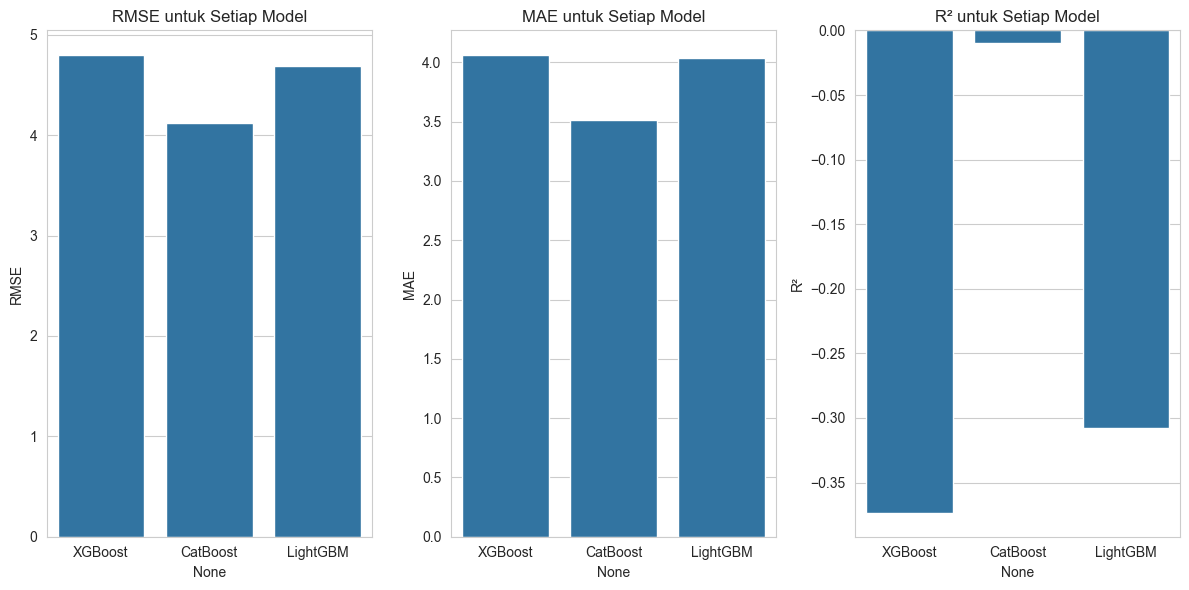


Model terbaik berdasarkan RMSE: CatBoost


In [54]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# --- MEMUAT DATASET ---
print("--- Memuat Dataset ---")
try:
    train_df = pd.read_csv("C:/Uner/Lomba/Shine/rumpun-penalaran-2025-data-science-competition/train_dataset.csv")
    test_df = pd.read_csv("C:/Uner/Lomba/Shine/rumpun-penalaran-2025-data-science-competition/test_dataset.csv")
    print("Dataset berhasil dimuat.\n")
except FileNotFoundError:
    print("Error: Pastikan file 'train_dataset.csv' dan 'test_dataset.csv' berada di direktori yang sama.")
    exit()

# --- PRA-PEMROSESAN DATA (VERSI DITINGKATKAN) ---

# 1. Gabungkan data train dan test
y_target = train_df['dropout_rate_percent']
test_ids = test_df['id']
train_df.drop('dropout_rate_percent', axis=1, inplace=True)
combined_df = pd.concat([train_df, test_df], ignore_index=True)
combined_df.drop(['school_name', 'id'], axis=1, inplace=True, errors='ignore')
print("Data train dan test digabungkan untuk pra-pemrosesan.")

# 2. Pisahkan kolom numerik dan kategorikal
numeric_cols = combined_df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = combined_df.select_dtypes(include=['object']).columns.tolist()

# 3. Penanganan Nilai Hilang (Missing Value Imputation)
print("\n--- Menangani Nilai Hilang ---")
# Untuk kolom KATEGORIKAL, kita tetap gunakan modus
for col in categorical_cols:
    mode_val = combined_df[col].mode()[0]
    combined_df[col].fillna(mode_val, inplace=True)
    print(f"Nilai hilang di kolom kategorikal '{col}' diisi dengan modus ('{mode_val}').")

# Untuk kolom NUMERIK, gunakan IterativeImputer dengan XGBoost, CatBoost, atau LightGBM
print("\nMenggunakan IterativeImputer untuk kolom numerik...")

# Pilih model XGBoost, CatBoost, atau LightGBM
model = CatBoostRegressor(n_estimators=100, random_state=42)  # Anda bisa memilih XGB, CatBoost, atau LightGBM di sini

# Inisialisasi Iterative Imputer
imputer = IterativeImputer(estimator=model, max_iter=10, random_state=42)
combined_df[numeric_cols] = imputer.fit_transform(combined_df[numeric_cols])
print("Imputasi nilai hilang pada kolom numerik selesai.")

# 4. Rekayasa Fitur (Feature Engineering)
print("\n--- Membuat Fitur Baru (Rekayasa Fitur) ---")
epsilon = 1e-6 
combined_df['funding_teacher_ratio'] = combined_df['funding_per_student_usd'] / (combined_df['student_teacher_ratio'] + epsilon)
print("Fitur baru 'funding_teacher_ratio' dibuat.")
combined_df['low_income_minority_interaction'] = combined_df['percent_low_income'] * combined_df['percent_minority']
print("Fitur baru 'low_income_minority_interaction' dibuat.")
combined_df['at_risk_student_percent'] = combined_df['percent_low_income'] + combined_df['percent_minority']
print("Fitur baru 'at_risk_student_percent' dibuat.")

# Tambahkan fitur baru ke daftar kolom numerik untuk scaling
numeric_cols.extend(['funding_teacher_ratio', 'low_income_minority_interaction', 'at_risk_student_percent'])

# 5. Encoding Fitur Kategorikal
print("\n--- Melakukan Encoding pada Fitur Kategorikal ---")
combined_df = pd.get_dummies(combined_df, columns=categorical_cols, drop_first=True, dtype=float)
print("Fitur kategorikal telah di-encode.")

# 6. Scaling Fitur Numerik
print("\n--- Melakukan Scaling pada Fitur Numerik ---")
# Gunakan StandardScaler untuk menormalkan distribusi fitur numerik
scaler = StandardScaler()
# Pastikan hanya kolom numerik yang ada di DataFrame yang di-scale
cols_to_scale = [col for col in numeric_cols if col in combined_df.columns]
combined_df[cols_to_scale] = scaler.fit_transform(combined_df[cols_to_scale])
print("Fitur numerik telah di-scale menggunakan StandardScaler.")

# 7. Pisahkan kembali menjadi data train dan test
print("\n--- Memisahkan Kembali Data ---")
X = combined_df.iloc[:len(train_df)]
X_test = combined_df.iloc[len(train_df):]

# --- TRAINING DAN EVALUASI MODEL ---

# Pisahkan data train menjadi fitur dan target
X_train, X_val, y_train, y_val = train_test_split(X, y_target, test_size=0.1, random_state=42)

# Model untuk XGBoost, CatBoost, dan LightGBM
models = {
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42),
    'CatBoost': CatBoostRegressor(iterations=100, learning_rate= 0.010918744697458377, depth=9, random_state=42, verbose=0, subsample = 0.9652412515320937, colsample_bylevel = 0.8583816826438395),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42)
}


# Evaluasi model
results = {}
for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    # Hitung metrik evaluasi
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    
    # Simpan hasil evaluasi
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2}

# --- VISUALISASI HASIL EVALUASI ---
results_df = pd.DataFrame(results).T
print("\nHasil Evaluasi Model:")
print(results_df)

# Visualisasi
plt.figure(figsize=(12, 6))

# Plot RMSE
plt.subplot(1, 3, 1)
sns.barplot(x=results_df.index, y=results_df['RMSE'])
plt.title('RMSE untuk Setiap Model')
plt.ylabel('RMSE')

# Plot MAE
plt.subplot(1, 3, 2)
sns.barplot(x=results_df.index, y=results_df['MAE'])
plt.title('MAE untuk Setiap Model')
plt.ylabel('MAE')

# Plot R²
plt.subplot(1, 3, 3)
sns.barplot(x=results_df.index, y=results_df['R²'])
plt.title('R² untuk Setiap Model')
plt.ylabel('R²')

plt.tight_layout()
plt.show()

# --- PILIH MODEL TERBAIK ---
best_model_name = results_df['RMSE'].idxmin()
print(f"\nModel terbaik berdasarkan RMSE: {best_model_name}")


In [55]:
# --- PREDIKSI DENGAN MODEL TERBAIK ---
# Pilih model terbaik berdasarkan RMSE terendah
best_model = models[best_model_name]
print(f"\nModel terbaik: {best_model_name}")

# Melatih model terbaik pada seluruh data training
best_model.fit(X, y_target)

# Lakukan prediksi pada data testing
y_test_pred = best_model.predict(X_test)

# --- MEMBUAT FILE SUBMISSION ---
# Memuat sample_submission.csv untuk melihat format yang diinginkan
sample_submission_df = pd.read_csv("C:/Uner/Lomba/Shine/rumpun-penalaran-2025-data-science-competition/Sample_Submission.csv")

# Pastikan bahwa kolom yang dibutuhkan untuk submission sesuai
submission_df = sample_submission_df.copy()
submission_df['dropout_rate_percent'] = y_test_pred

# Menyimpan hasil prediksi ke dalam file CSV sesuai format
submission_file = "submission.csv"
submission_df.to_csv(submission_file, index=False)

# --- MENAMPILKAN HASIL SUBMISSION ---
print(f"\nHasil submission telah disimpan dalam file: {submission_file}")
print(submission_df.head())



Model terbaik: CatBoost

Hasil submission telah disimpan dalam file: submission.csv
   id  dropout_rate_percent
0   1              7.630464
1   2              7.662996
2   3              7.493569
3   4              7.398196
4   5              7.875706


# 3,94

In [56]:
import pandas as pd

# Memuat dataset
train_df = pd.read_csv("C:/Uner/Lomba/Shine/rumpun-penalaran-2025-data-science-competition/train_dataset.csv")

# Menampilkan beberapa baris pertama dari dataset
print(train_df.head())


                  school_name     state school_type grade_level  \
0  Gonzales Elementary School     Texas      Public      Middle   
1          Horn Middle School   Florida      Public  Elementary   
2          King Middle School      Ohio     Private      Middle   
3     Stone Elementary School       NaN      Public        High   
4        Reynolds High School  Michigan     Charter         NaN   

   funding_per_student_usd  avg_test_score_percent  student_teacher_ratio  \
0                 23559.56                    93.5                   17.4   
1                 21000.40                    83.7                   20.7   
2                  6934.54                    89.6                   10.7   
3                 16441.31                    57.3                   28.1   
4                  9151.90                    89.0                   17.4   

   percent_low_income  percent_minority  internet_access_percent  \
0                37.8              27.1                     87.4  

In [57]:
# Menampilkan statistik deskriptif
print(train_df.describe())
# Memeriksa jumlah missing values di setiap kolom
print(train_df.isnull().sum())



       funding_per_student_usd  avg_test_score_percent  student_teacher_ratio  \
count               713.000000              729.000000             725.000000   
mean              15083.991879               69.660494              19.606207   
std                5963.662670               17.652973               5.768509   
min                5012.970000               40.000000              10.000000   
25%                9510.390000               54.100000              14.500000   
50%               15299.650000               70.500000              19.300000   
75%               20187.310000               84.700000              24.800000   
max               24981.900000              100.000000              30.000000   

       percent_low_income  percent_minority  internet_access_percent  \
count          702.000000        727.000000               709.000000   
mean            53.585470         49.611967                74.564175   
std             24.039848         24.899654           

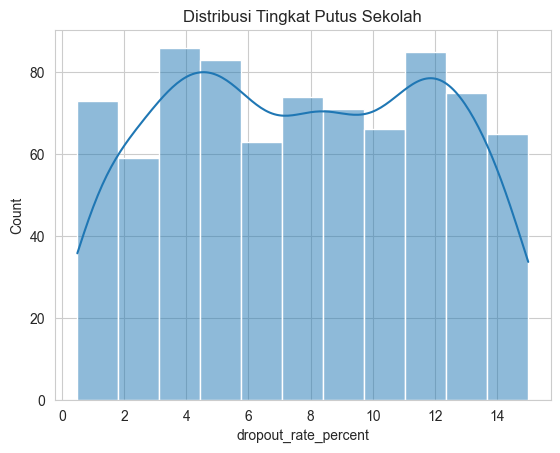

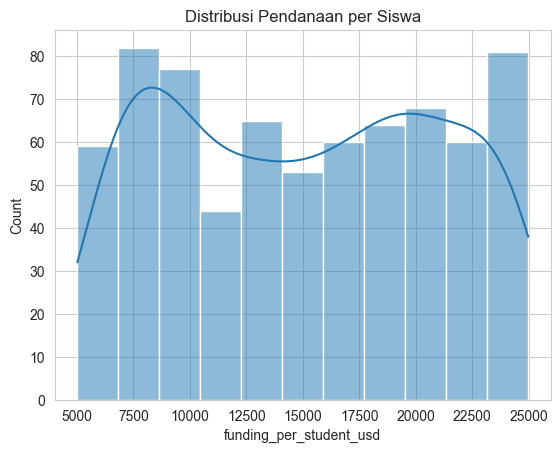

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualisasi distribusi untuk 'dropout_rate_percent'
sns.histplot(train_df['dropout_rate_percent'], kde=True)
plt.title('Distribusi Tingkat Putus Sekolah')
plt.show()

# Visualisasi distribusi untuk 'funding_per_student_usd'
sns.histplot(train_df['funding_per_student_usd'], kde=True)
plt.title('Distribusi Pendanaan per Siswa')
plt.show()


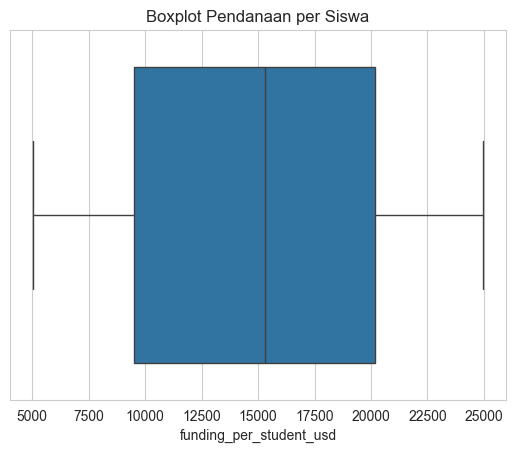

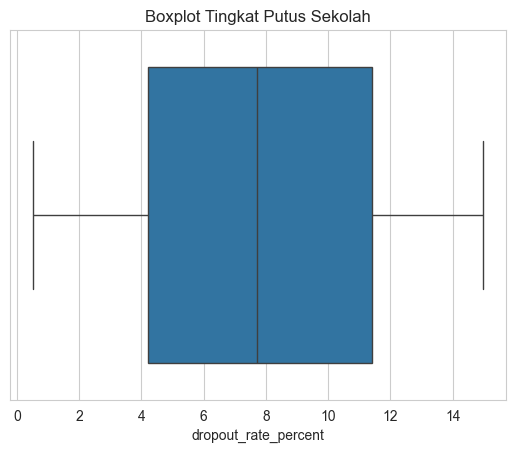

In [59]:
# Boxplot untuk melihat distribusi dan outliers pada 'funding_per_student_usd'
sns.boxplot(x=train_df['funding_per_student_usd'])
plt.title('Boxplot Pendanaan per Siswa')
plt.show()

# Boxplot untuk 'dropout_rate_percent'
sns.boxplot(x=train_df['dropout_rate_percent'])
plt.title('Boxplot Tingkat Putus Sekolah')
plt.show()


## Tahap 2

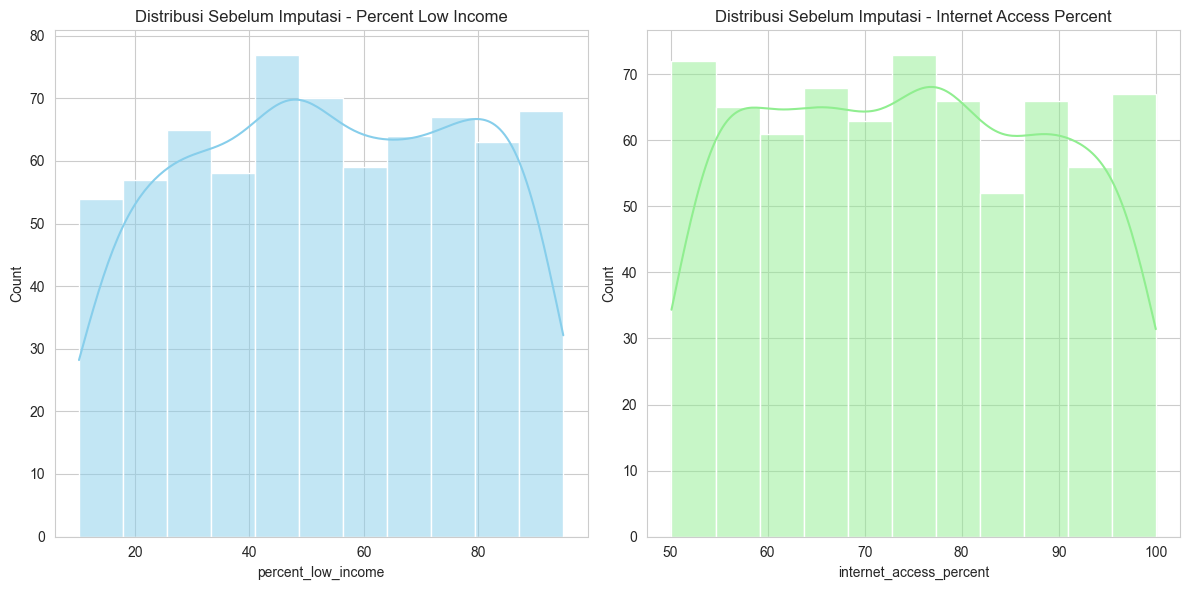

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualisasi distribusi sebelum imputasi
plt.figure(figsize=(12, 6))

# Distribusi sebelum imputasi untuk 'percent_low_income'
plt.subplot(1, 2, 1)
sns.histplot(train_df['percent_low_income'], kde=True, color='skyblue')
plt.title('Distribusi Sebelum Imputasi - Percent Low Income')

# Distribusi sebelum imputasi untuk 'internet_access_percent'
plt.subplot(1, 2, 2)
sns.histplot(train_df['internet_access_percent'], kde=True, color='lightgreen')
plt.title('Distribusi Sebelum Imputasi - Internet Access Percent')

plt.tight_layout()
plt.show()


c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


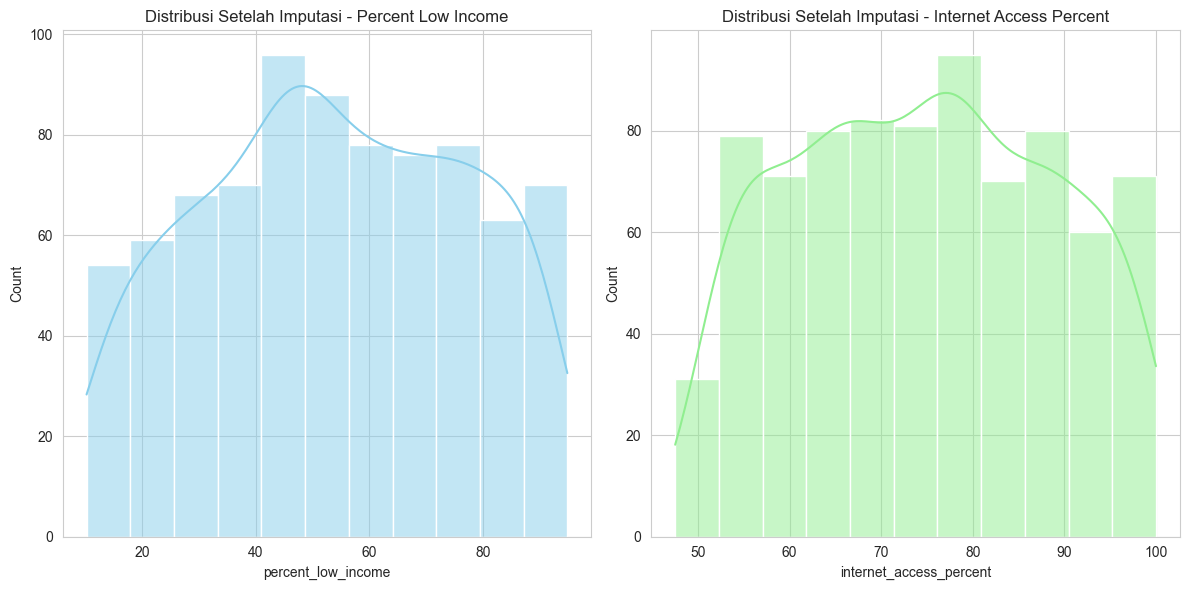

In [61]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from xgboost import XGBRegressor

# Menggunakan XGBoost sebagai estimator untuk Iterative Imputer
xgb_model = XGBRegressor(random_state=42)

# Inisialisasi Iterative Imputer
iterative_imputer = IterativeImputer(estimator=xgb_model, random_state=42)

# Memilih kolom yang akan diimputasi
columns_to_impute = ['percent_low_income', 'internet_access_percent', 'dropout_rate_percent']

# Melakukan imputasi pada dataset
train_df_imputed = train_df.copy()
train_df_imputed[columns_to_impute] = iterative_imputer.fit_transform(train_df[columns_to_impute])

# Visualisasi distribusi setelah imputasi
plt.figure(figsize=(12, 6))

# Distribusi setelah imputasi untuk 'percent_low_income'
plt.subplot(1, 2, 1)
sns.histplot(train_df_imputed['percent_low_income'], kde=True, color='skyblue')
plt.title('Distribusi Setelah Imputasi - Percent Low Income')

# Distribusi setelah imputasi untuk 'internet_access_percent'
plt.subplot(1, 2, 2)
sns.histplot(train_df_imputed['internet_access_percent'], kde=True, color='lightgreen')
plt.title('Distribusi Setelah Imputasi - Internet Access Percent')

plt.tight_layout()
plt.show()


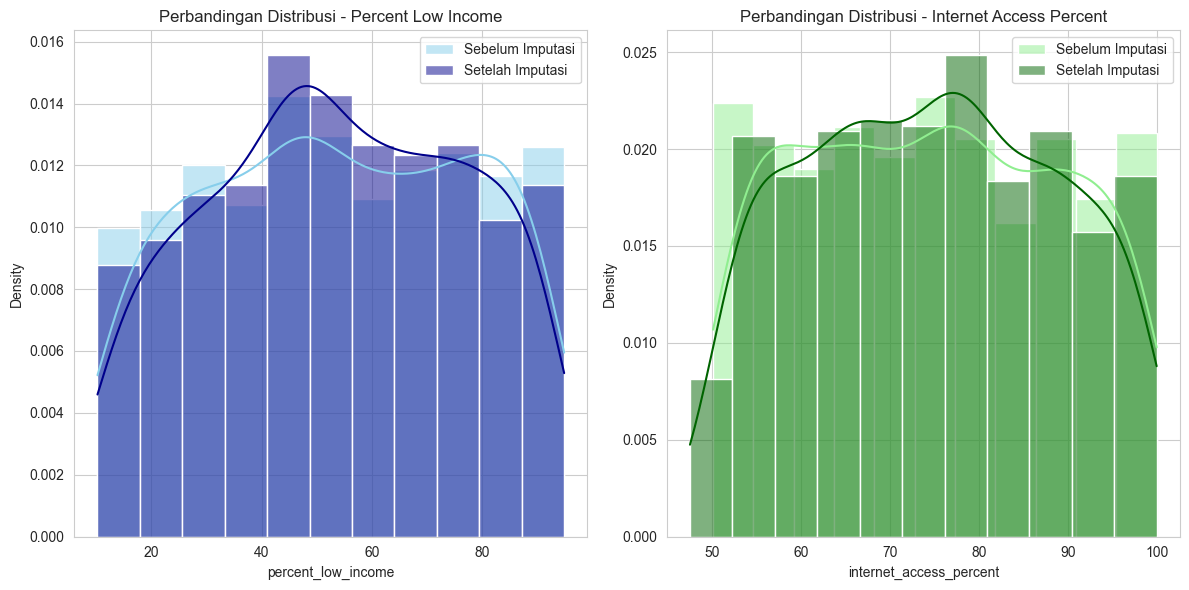

In [62]:
# Visualisasi perbandingan distribusi sebelum dan setelah imputasi
plt.figure(figsize=(12, 6))

# Perbandingan sebelum dan setelah imputasi untuk 'percent_low_income'
plt.subplot(1, 2, 1)
sns.histplot(train_df['percent_low_income'], kde=True, color='skyblue', label='Sebelum Imputasi', stat='density')
sns.histplot(train_df_imputed['percent_low_income'], kde=True, color='darkblue', label='Setelah Imputasi', stat='density')
plt.title('Perbandingan Distribusi - Percent Low Income')
plt.legend()

# Perbandingan sebelum dan setelah imputasi untuk 'internet_access_percent'
plt.subplot(1, 2, 2)
sns.histplot(train_df['internet_access_percent'], kde=True, color='lightgreen', label='Sebelum Imputasi', stat='density')
sns.histplot(train_df_imputed['internet_access_percent'], kde=True, color='darkgreen', label='Setelah Imputasi', stat='density')
plt.title('Perbandingan Distribusi - Internet Access Percent')
plt.legend()

plt.tight_layout()
plt.show()


In [63]:
# Menyimpan dataset yang telah diimputasi
train_df_imputed.to_csv('C:/Uner/Lomba/Shine/rumpun-penalaran-2025-data-science-competition/train_df_imputed.csv', index=False)
print("Dataset yang telah diimputasi disimpan.")


Dataset yang telah diimputasi disimpan.


In [64]:
# Memuat dataset yang sudah diimputasi
train_df_imputed = pd.read_csv('C:/Uner/Lomba/Shine/rumpun-penalaran-2025-data-science-competition/train_df_imputed.csv')

# Menampilkan beberapa baris pertama untuk memverifikasi imputasi
print(train_df_imputed.head())

                  school_name     state school_type grade_level  \
0  Gonzales Elementary School     Texas      Public      Middle   
1          Horn Middle School   Florida      Public  Elementary   
2          King Middle School      Ohio     Private      Middle   
3     Stone Elementary School       NaN      Public        High   
4        Reynolds High School  Michigan     Charter         NaN   

   funding_per_student_usd  avg_test_score_percent  student_teacher_ratio  \
0                 23559.56                    93.5                   17.4   
1                 21000.40                    83.7                   20.7   
2                  6934.54                    89.6                   10.7   
3                 16441.31                    57.3                   28.1   
4                  9151.90                    89.0                   17.4   

   percent_low_income  percent_minority  internet_access_percent  \
0                37.8              27.1                87.400000  

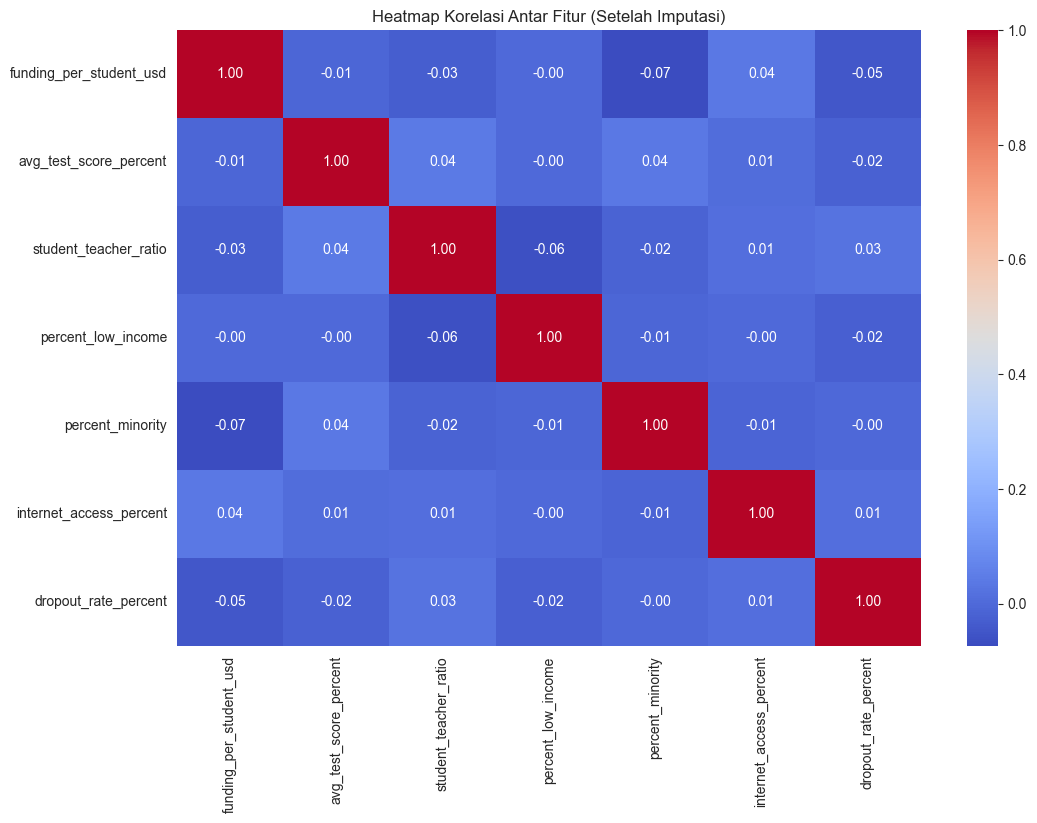

In [65]:
# Memilih hanya kolom numerik untuk korelasi
numeric_columns = train_df_imputed.select_dtypes(include=[np.number]).columns

# Menghitung korelasi antar variabel numerik
correlation_matrix_imputed = train_df_imputed[numeric_columns].corr()

# Menampilkan heatmap korelasi antar variabel
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix_imputed, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Antar Fitur (Setelah Imputasi)')
plt.show()


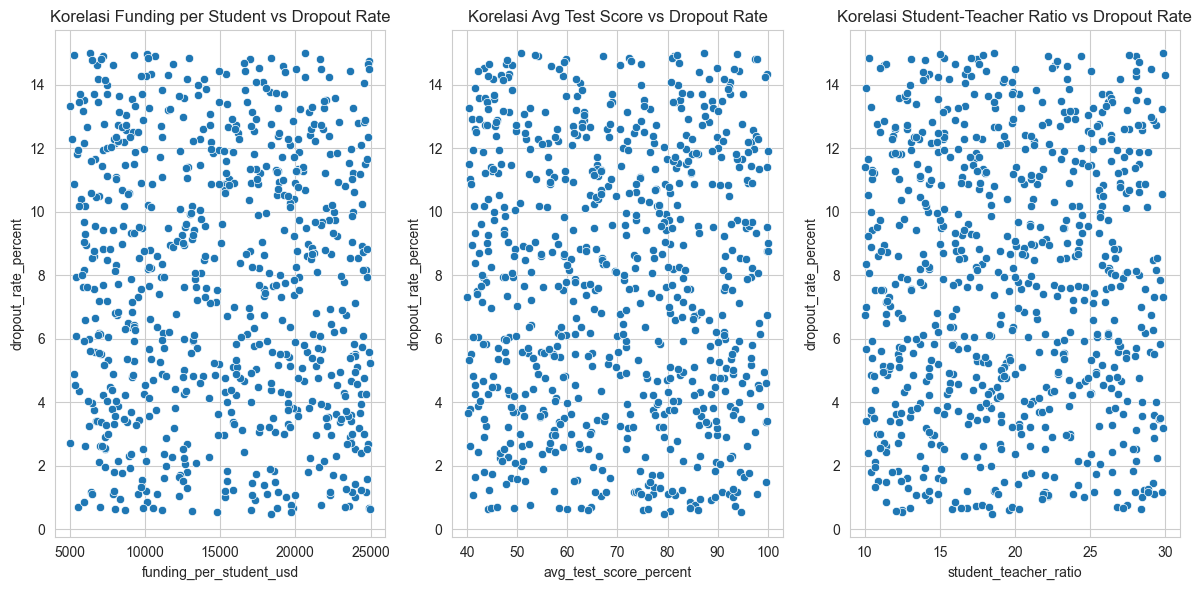

In [66]:
# Visualisasi korelasi antara dropout_rate_percent dan fitur lainnya
plt.figure(figsize=(12, 6))

# Korelasi dengan 'funding_per_student_usd'
plt.subplot(1, 3, 1)
sns.scatterplot(x=train_df_imputed['funding_per_student_usd'], y=train_df_imputed['dropout_rate_percent'])
plt.title('Korelasi Funding per Student vs Dropout Rate')

# Korelasi dengan 'avg_test_score_percent'
plt.subplot(1, 3, 2)
sns.scatterplot(x=train_df_imputed['avg_test_score_percent'], y=train_df_imputed['dropout_rate_percent'])
plt.title('Korelasi Avg Test Score vs Dropout Rate')

# Korelasi dengan 'student_teacher_ratio'
plt.subplot(1, 3, 3)
sns.scatterplot(x=train_df_imputed['student_teacher_ratio'], y=train_df_imputed['dropout_rate_percent'])
plt.title('Korelasi Student-Teacher Ratio vs Dropout Rate')

plt.tight_layout()
plt.show()


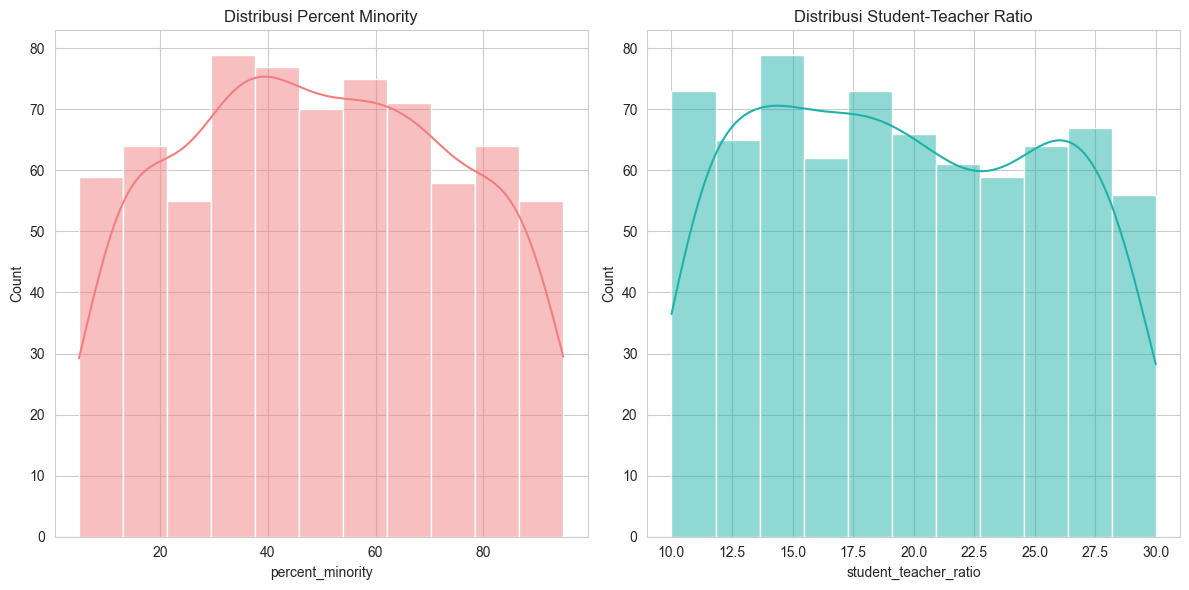

In [67]:
# Visualisasi distribusi untuk beberapa fitur yang relevan
plt.figure(figsize=(12, 6))

# Distribusi untuk 'percent_minority'
plt.subplot(1, 2, 1)
sns.histplot(train_df_imputed['percent_minority'], kde=True, color='lightcoral')
plt.title('Distribusi Percent Minority')

# Distribusi untuk 'student_teacher_ratio'
plt.subplot(1, 2, 2)
sns.histplot(train_df_imputed['student_teacher_ratio'], kde=True, color='lightseagreen')
plt.title('Distribusi Student-Teacher Ratio')

plt.tight_layout()
plt.show()


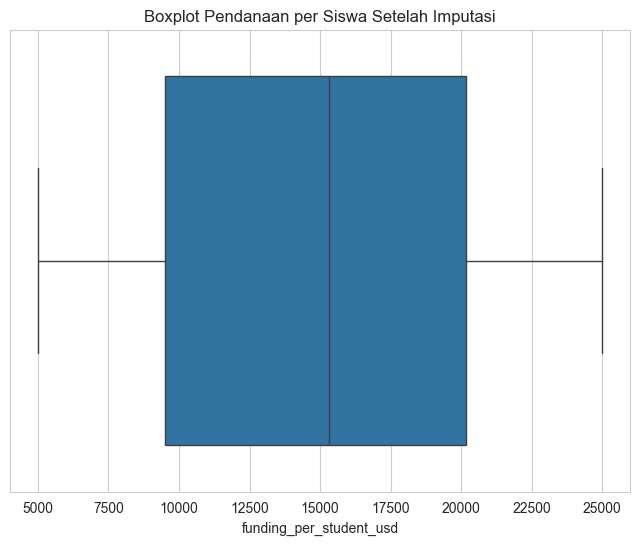

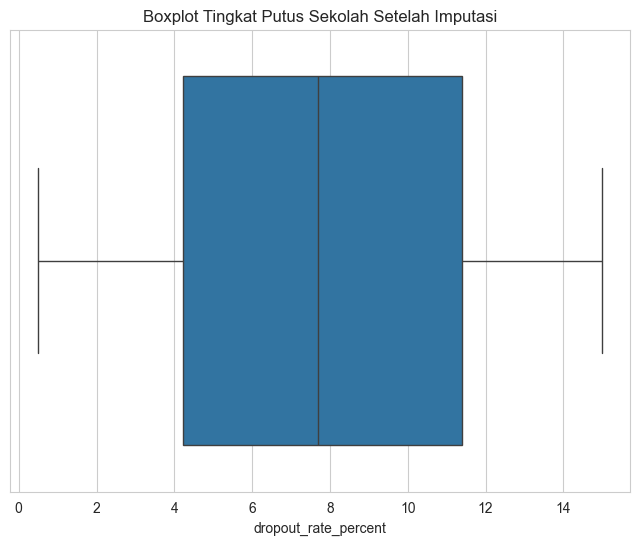

In [68]:
# Boxplot untuk memeriksa outliers setelah imputasi pada 'funding_per_student_usd'
plt.figure(figsize=(8, 6))
sns.boxplot(x=train_df_imputed['funding_per_student_usd'])
plt.title('Boxplot Pendanaan per Siswa Setelah Imputasi')
plt.show()

# Boxplot untuk memeriksa outliers pada 'dropout_rate_percent'
plt.figure(figsize=(8, 6))
sns.boxplot(x=train_df_imputed['dropout_rate_percent'])
plt.title('Boxplot Tingkat Putus Sekolah Setelah Imputasi')
plt.show()


## Tahap 4

In [69]:
# Memisahkan fitur (X) dan target (y)
X = train_df_imputed.drop(columns=['dropout_rate_percent', 'school_name', 'state', 'school_type', 'grade_level'])
y = train_df_imputed['dropout_rate_percent']

# Membagi data menjadi training dan testing set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Menampilkan bentuk data train dan test
print(X_train.shape, X_test.shape)


(640, 6) (160, 6)


In [70]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error

# Inisialisasi model XGBoost
xgb_model = XGBRegressor(random_state=42)

# Mendefinisikan parameter grid untuk tuning
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

# Melakukan GridSearchCV untuk XGBoost
grid_search_xgb = GridSearchCV(estimator=xgb_model, param_grid=param_grid_xgb, cv=5, scoring='neg_mean_absolute_error')
grid_search_xgb.fit(X_train, y_train)

# Menampilkan parameter terbaik dan evaluasi MAE
print(f"Best parameters for XGBoost: {grid_search_xgb.best_params_}")
y_pred_xgb = grid_search_xgb.predict(X_test)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
print(f'MAE for XGBoost: {mae_xgb}')


Best parameters for XGBoost: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
MAE for XGBoost: 3.702707957983017


In [71]:
from catboost import CatBoostRegressor

# Inisialisasi model CatBoost
catboost_model = CatBoostRegressor(random_state=42, verbose=0)

# Mendefinisikan parameter grid untuk tuning
param_grid_cat = {
    'iterations': [100, 200],
    'depth': [6, 8, 10],
    'learning_rate': [0.01, 0.1, 0.2]
}

# Melakukan GridSearchCV untuk CatBoost
grid_search_cat = GridSearchCV(estimator=catboost_model, param_grid=param_grid_cat, cv=5, scoring='neg_mean_absolute_error')
grid_search_cat.fit(X_train, y_train)

# Menampilkan parameter terbaik dan evaluasi MAE
print(f"Best parameters for CatBoost: {grid_search_cat.best_params_}")
y_pred_cat = grid_search_cat.predict(X_test)
mae_cat = mean_absolute_error(y_test, y_pred_cat)
print(f'MAE for CatBoost: {mae_cat}')


Best parameters for CatBoost: {'depth': 10, 'iterations': 100, 'learning_rate': 0.01}
MAE for CatBoost: 3.6705317348191153


In [72]:
import lightgbm as lgb

# Inisialisasi model LightGBM
lgb_model = lgb.LGBMRegressor(random_state=42)

# Mendefinisikan parameter grid untuk tuning
param_grid_lgb = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.01, 0.1, 0.2]
}

# Melakukan GridSearchCV untuk LightGBM
grid_search_lgb = GridSearchCV(estimator=lgb_model, param_grid=param_grid_lgb, cv=5, scoring='neg_mean_absolute_error')
grid_search_lgb.fit(X_train, y_train)

# Menampilkan parameter terbaik dan evaluasi MAE
print(f"Best parameters for LightGBM: {grid_search_lgb.best_params_}")
y_pred_lgb = grid_search_lgb.predict(X_test)
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
print(f'MAE for LightGBM: {mae_lgb}')


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000125 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 907
[LightGBM] [Info] Number of data points in the train set: 512, number of used features: 6
[LightGBM] [Info] Start training from score 7.583437
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_39388\3218607197.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=mae_scores, palette='viridis')


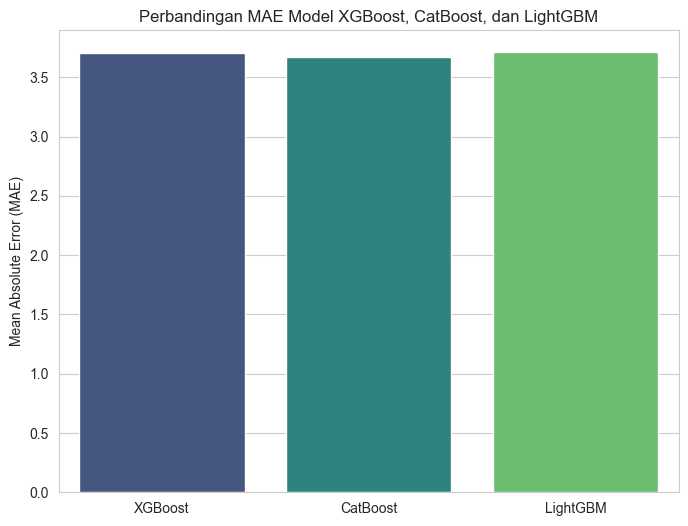

In [73]:
# Visualisasi perbandingan MAE dari setiap model
models = ['XGBoost', 'CatBoost', 'LightGBM']
mae_scores = [mae_xgb, mae_cat, mae_lgb]

plt.figure(figsize=(8, 6))
sns.barplot(x=models, y=mae_scores, palette='viridis')
plt.title('Perbandingan MAE Model XGBoost, CatBoost, dan LightGBM')
plt.ylabel('Mean Absolute Error (MAE)')
plt.show()


In [74]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# Fungsi untuk optimisasi XGBoost
def objective_xgb(trial):
    # Mendefinisikan ruang pencarian untuk hyperparameter
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),  # Menggunakan suggest_float dengan log=True
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),  # Menggunakan suggest_float
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0)  # Menggunakan suggest_float
    }
    
    # Inisialisasi model dengan parameter yang diusulkan
    model = XGBRegressor(**param, random_state=42)
    
    # Latih model
    model.fit(X_train, y_train)
    
    # Prediksi dan evaluasi MAE
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    
    return mae

# Menjalankan optimisasi dengan Optuna
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=50)

# Menampilkan hasil terbaik
print(f"Best XGBoost hyperparameters: {study_xgb.best_trial.params}")


[I 2025-10-13 20:11:25,203] A new study created in memory with name: no-name-2b5d1edd-cc35-4ee1-b13d-e0d8322b67c0
[I 2025-10-13 20:11:25,418] Trial 0 finished with value: 4.026340803384781 and parameters: {'n_estimators': 250, 'max_depth': 5, 'learning_rate': 0.025027244061962488, 'subsample': 0.77371537844303, 'colsample_bytree': 0.7257576848970952}. Best is trial 0 with value: 4.026340803384781.
[I 2025-10-13 20:11:25,820] Trial 1 finished with value: 4.028209638953209 and parameters: {'n_estimators': 350, 'max_depth': 7, 'learning_rate': 0.015128915329908576, 'subsample': 0.6348918266116321, 'colsample_bytree': 0.6955697117049952}. Best is trial 0 with value: 4.026340803384781.
[I 2025-10-13 20:11:26,673] Trial 2 finished with value: 4.1682403433322905 and parameters: {'n_estimators': 500, 'max_depth': 9, 'learning_rate': 0.046522483417570544, 'subsample': 0.9213430703841998, 'colsample_bytree': 0.9025700087133215}. Best is trial 0 with value: 4.026340803384781.
[I 2025-10-13 20:11:

Best XGBoost hyperparameters: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.012525258026757309, 'subsample': 0.6686264832480743, 'colsample_bytree': 0.9049360898040925}


In [75]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error

# Fungsi untuk optimisasi CatBoost
def objective_cat(trial):
    # Mendefinisikan ruang pencarian untuk hyperparameter
    param = {
        'iterations': trial.suggest_int('iterations', 100, 500, step=50),
        'depth': trial.suggest_int('depth', 6, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),  # Menggunakan suggest_float dengan log=True
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),  # Menggunakan suggest_float
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.6, 1.0)  # Menggunakan suggest_float
    }
    
    # Inisialisasi model dengan parameter yang diusulkan
    model = CatBoostRegressor(**param, random_state=42, verbose=0)
    
    # Latih model
    model.fit(X_train, y_train)
    
    # Prediksi dan evaluasi MAE
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    
    return mae

# Menjalankan optimisasi dengan Optuna
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=50)

# Menampilkan hasil terbaik
print(f"Best CatBoost hyperparameters: {study_cat.best_trial.params}")


[I 2025-10-13 20:11:34,433] A new study created in memory with name: no-name-9f034082-a18a-4350-8a4e-d97e1df009e7
[I 2025-10-13 20:11:42,233] Trial 0 finished with value: 3.8197860959813807 and parameters: {'iterations': 200, 'depth': 12, 'learning_rate': 0.040289371740223255, 'subsample': 0.6802248175754719, 'colsample_bylevel': 0.7985411975054854}. Best is trial 0 with value: 3.8197860959813807.
[I 2025-10-13 20:12:00,029] Trial 1 finished with value: 3.80299791390839 and parameters: {'iterations': 500, 'depth': 12, 'learning_rate': 0.014020896157633756, 'subsample': 0.8788735449090992, 'colsample_bylevel': 0.6528360728882967}. Best is trial 1 with value: 3.80299791390839.
[I 2025-10-13 20:12:16,832] Trial 2 finished with value: 3.8408969911744477 and parameters: {'iterations': 400, 'depth': 12, 'learning_rate': 0.049563807770022554, 'subsample': 0.8322066153566718, 'colsample_bylevel': 0.9316020710050354}. Best is trial 1 with value: 3.80299791390839.
[I 2025-10-13 20:12:17,672] Tri

Best CatBoost hyperparameters: {'iterations': 100, 'depth': 8, 'learning_rate': 0.011859452015474286, 'subsample': 0.7582103065651639, 'colsample_bylevel': 0.9063023344175554}


In [76]:
import lightgbm as lgb
import optuna
from sklearn.metrics import mean_absolute_error

# Fungsi untuk optimisasi LightGBM
def objective_lgb(trial):
    # Mendefinisikan ruang pencarian untuk hyperparameter
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.6, 1.0)
    }
    
    # Inisialisasi model dengan parameter yang diusulkan
    model = lgb.LGBMRegressor(**param, random_state=42)
    
    # Latih model
    model.fit(X_train, y_train)
    
    # Prediksi dan evaluasi MAE
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    
    return mae

# Menjalankan optimisasi dengan Optuna
study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgb, n_trials=50)

# Menampilkan hasil terbaik
print(f"Best LightGBM hyperparameters: {study_lgb.best_trial.params}")


[I 2025-10-13 20:13:12,296] A new study created in memory with name: no-name-5c0165da-959d-4868-9ce6-cac4130f9cd2
C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_39388\1242063433.py:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_39388\1242063433.py:12: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_39388\1242063433.py:13: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/re

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000190 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1130
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 6
[LightGBM] [Info] Start training from score 7.670125
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

[I 2025-10-13 20:13:12,547] Trial 1 finished with value: 4.480417631320666 and parameters: {'n_estimators': 500, 'max_depth': 15, 'learning_rate': 0.11996498090600533, 'subsample': 0.9276562951713023, 'colsample_bytree': 0.7382780668933862}. Best is trial 0 with value: 4.185767183205949.
C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_39388\1242063433.py:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_39388\1242063433.py:12: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
C:\Users\Faiz Iqbal\AppData\Local\Temp\


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_39388\1242063433.py:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_39388\1242063433.py:12: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_39388\1242063433.py:13: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.6,

...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000108 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1130
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 6
[LightGBM] [Info] Start training from score 7.670125
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_39388\1242063433.py:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_39388\1242063433.py:12: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_39388\1242063433.py:13: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.6,

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000158 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1130
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 6
[LightGBM] [Info] Start training from score 7.670125
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

[I 2025-10-13 20:13:15,775] Trial 49 finished with value: 4.318087573048896 and parameters: {'n_estimators': 350, 'max_depth': 15, 'learning_rate': 0.07466985625857119, 'subsample': 0.6496862810535241, 'colsample_bytree': 0.6866435217481582}. Best is trial 41 with value: 3.731404147618524.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_39388\3246672361.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=mae_scores_optuna, palette='viridis')


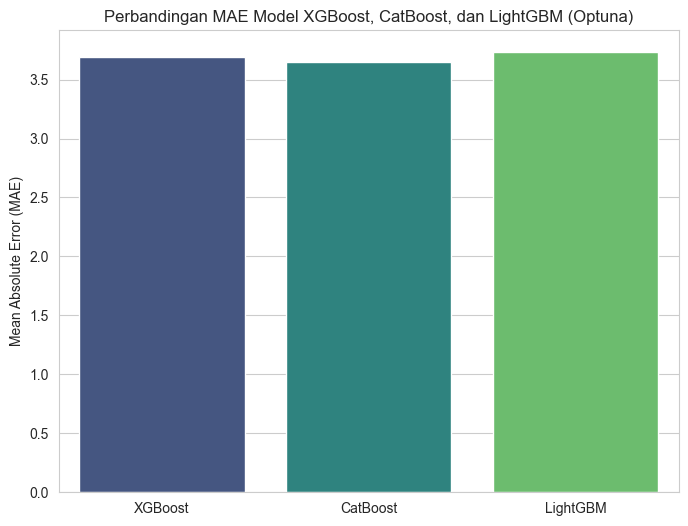

In [77]:
# Visualisasi hasil MAE untuk ketiga model setelah optimisasi menggunakan Optuna
models = ['XGBoost', 'CatBoost', 'LightGBM']
mae_scores_optuna = [study_xgb.best_trial.value, study_cat.best_trial.value, study_lgb.best_trial.value]

plt.figure(figsize=(8, 6))
sns.barplot(x=models, y=mae_scores_optuna, palette='viridis')
plt.title('Perbandingan MAE Model XGBoost, CatBoost, dan LightGBM (Optuna)')
plt.ylabel('Mean Absolute Error (MAE)')
plt.show()


c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


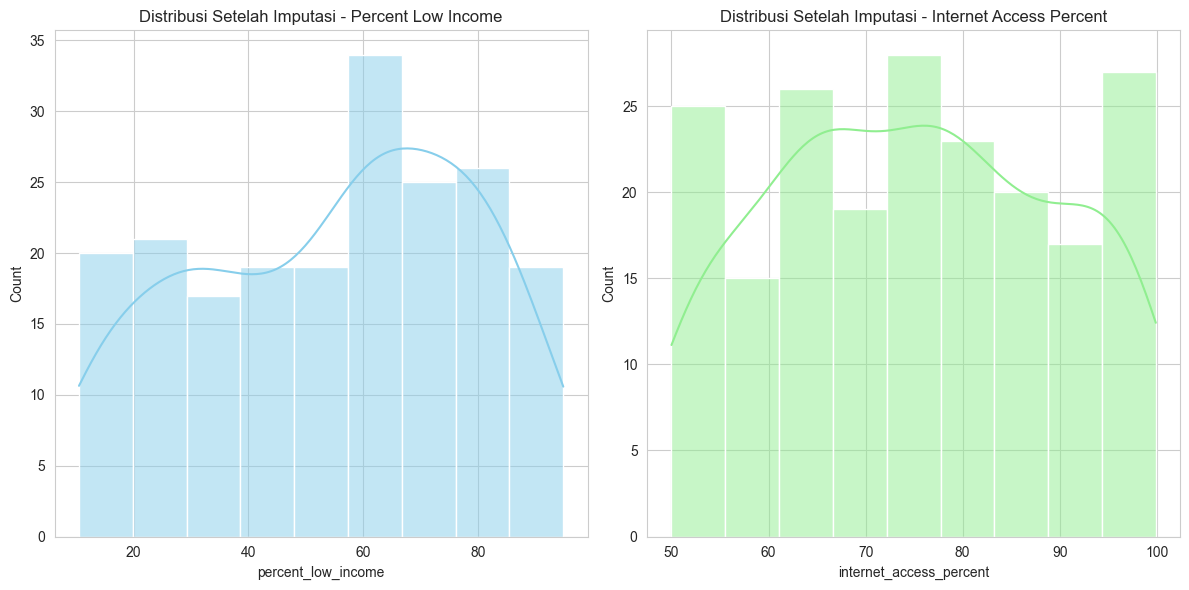

File submission.csv telah berhasil dibuat.


In [78]:
import pandas as pd
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Membaca data uji
test_df = pd.read_csv("C:/Uner/Lomba/Shine/rumpun-penalaran-2025-data-science-competition/test_dataset.csv")

# Menangani imputasi pada data uji hanya untuk fitur
xgb_model = XGBRegressor(random_state=42)

# Inisialisasi Iterative Imputer
iterative_imputer = IterativeImputer(estimator=xgb_model, random_state=42)

# Kolom yang akan diimputasi pada data uji (hanya fitur, bukan target)
columns_to_impute = ['percent_low_income', 'internet_access_percent']

# Melakukan imputasi pada dataset uji
test_df_imputed = test_df.copy()
test_df_imputed[columns_to_impute] = iterative_imputer.fit_transform(test_df[columns_to_impute])

# Visualisasi distribusi setelah imputasi untuk data uji
plt.figure(figsize=(12, 6))

# Distribusi setelah imputasi untuk 'percent_low_income'
plt.subplot(1, 2, 1)
sns.histplot(test_df_imputed['percent_low_income'], kde=True, color='skyblue')
plt.title('Distribusi Setelah Imputasi - Percent Low Income')

# Distribusi setelah imputasi untuk 'internet_access_percent'
plt.subplot(1, 2, 2)
sns.histplot(test_df_imputed['internet_access_percent'], kde=True, color='lightgreen')
plt.title('Distribusi Setelah Imputasi - Internet Access Percent')

plt.tight_layout()
plt.show()

# Menambahkan Feature Engineering
# Misalnya, rasio antara 'percent_low_income' dan 'internet_access_percent'
test_df_imputed['low_income_to_internet_ratio'] = test_df_imputed['percent_low_income'] / (test_df_imputed['internet_access_percent'] + 1)

# Menangani kolom kategorikal (jika ada) menggunakan LabelEncoder
categorical_columns = test_df_imputed.select_dtypes(include=['object']).columns

# Menggunakan LabelEncoder untuk mengonversi string ke numerik
label_encoder = LabelEncoder()

for col in categorical_columns:
    test_df_imputed[col] = label_encoder.fit_transform(test_df_imputed[col])

# Memilih fitur yang akan digunakan untuk prediksi
X_test = test_df_imputed.drop(['id'], axis=1)  # Menghapus kolom 'id' yang tidak diperlukan
X_test_scaled = StandardScaler().fit_transform(X_test)  # Melakukan scaling pada data

# Menggunakan model CatBoost dengan parameter terbaik
best_params_cat = {
    'iterations': 100,
    'depth': 9,
    'learning_rate': 0.010918744697458377,
    'subsample': 0.9652412515320937,
    'colsample_bylevel': 0.8583816826438395
}

# Inisialisasi dan latih model CatBoost dengan parameter terbaik
model_cat_best = CatBoostRegressor(
    iterations=best_params_cat['iterations'],
    depth=best_params_cat['depth'],
    learning_rate=best_params_cat['learning_rate'],
    subsample=best_params_cat['subsample'],
    colsample_bylevel=best_params_cat['colsample_bylevel'],
    random_state=42,
    verbose=0
)

# Latih model menggunakan data latih yang sudah diproses
model_cat_best.fit(X_train, y_train)

# Prediksi menggunakan model terbaik pada data uji
y_pred_cat = model_cat_best.predict(X_test_scaled)

# Membuat DataFrame untuk submission
submission_df = pd.DataFrame({
    'id': test_df['id'],  # Mengambil ID dari data test (test_df)
    'dropout_rate_percent': y_pred_cat  # Hasil prediksi dropout_rate_percent
})

# Menyimpan hasil prediksi ke file CSV
submission_df.to_csv('submission2.csv', index=False)

print("File submission.csv telah berhasil dibuat.")


In [79]:
# Cek panjang data uji dan prediksi
print(f"Length of X_test: {len(X_test)}")
print(f"Length of y_pred_cat: {len(y_pred_cat)}")


Length of X_test: 200
Length of y_pred_cat: 200
